# Data Exploration
This notebook is just to get an idea about what each variable encodes and to do some basic visualization.

## Import Packages

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [ ]:
thyroid_df = pd.read_csv("Thyroid-Dataset.csv")
thyroid_df.info()
thyroid_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        9171 non-null   int64  
 1   sex                        8864 non-null   object 
 2   on thyroxine               9171 non-null   bool   
 3   query on thyroxine         9171 non-null   bool   
 4   on antithyroid medication  9171 non-null   bool   
 5   sick                       9171 non-null   bool   
 6   pregnant                   9171 non-null   bool   
 7   thyroid surgery            9171 non-null   bool   
 8   I131 treatment             9171 non-null   bool   
 9   query hypothyroid          9171 non-null   bool   
 10  query hyperthyroid         9171 non-null   bool   
 11  lithium                    9171 non-null   bool   
 12  goitre                     9171 non-null   bool   
 13  tumor                      9171 non-null   bool 

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
0,29,F,False,False,False,False,False,False,False,False,...,False,False,False,1.6,1.9,128.0,NaN,NaN,other,negative
1,41,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,negative
2,36,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,negative
3,32,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,miscellaneous
4,60,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,negative


## Explore Boolean Variables
No missing data but that is likely becuase false was the default entry. All variables heavily favor false.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   on thyroxine               9171 non-null   bool 
 1   query on thyroxine         9171 non-null   bool 
 2   on antithyroid medication  9171 non-null   bool 
 3   sick                       9171 non-null   bool 
 4   pregnant                   9171 non-null   bool 
 5   thyroid surgery            9171 non-null   bool 
 6   I131 treatment             9171 non-null   bool 
 7   query hypothyroid          9171 non-null   bool 
 8   query hyperthyroid         9171 non-null   bool 
 9   lithium                    9171 non-null   bool 
 10  goitre                     9171 non-null   bool 
 11  tumor                      9171 non-null   bool 
 12  hypopituitary              9171 non-null   bool 
 13  psych                      9171 non-null   bool 
dtypes: bool(14)
memory usage

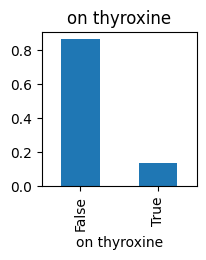

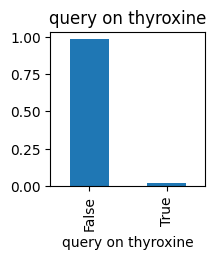

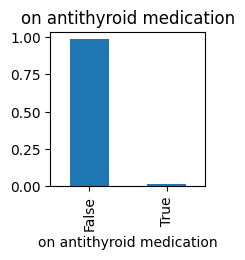

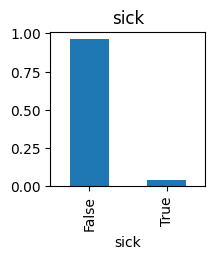

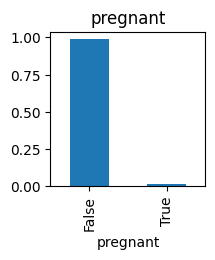

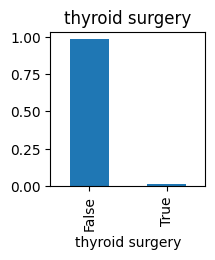

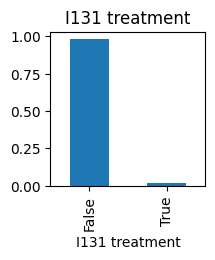

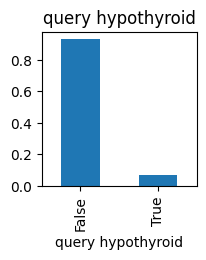

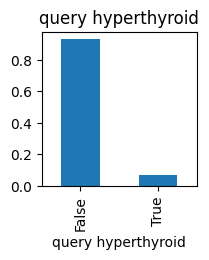

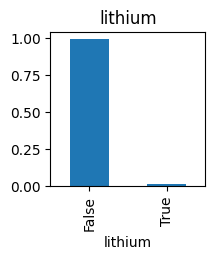

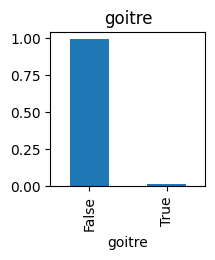

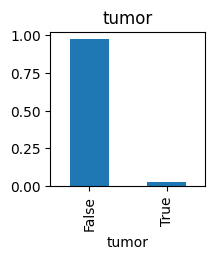

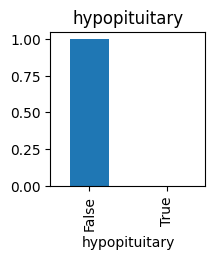

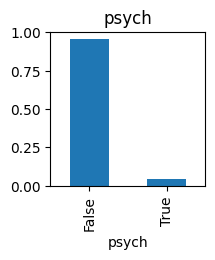

In [99]:
bool_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'bool'].index
thyroid_df[bool_cols].info()
for col in bool_cols:
    thyroid_df[col].value_counts(normalize=True).plot(kind='bar', figsize=(2, 2))
    plt.ylabel('')
    plt.title(col)
    plt.show()
    plt.close()

## Explore Float Variables
All variables have a considerable number of potential outliers, but upon cursory examination it did not appear that any were obvious errors.

All variables also have missing values. Might be best to create flag variables to determine if the missing data is correlated to anything else in the dataset.

In [100]:
float_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'float64'].index
thyroid_df[float_cols].info()
thyroid_df[float_cols].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TSH     8329 non-null   float64
 1   T3      6568 non-null   float64
 2   TT4     8730 non-null   float64
 3   T4U     8363 non-null   float64
 4   FTI     8370 non-null   float64
dtypes: float64(5)
memory usage: 358.4 KB


,TSH,T3,TT4,T4U,FTI
count,8329.000000,6568.000000,8730.000000,8363.000000,8370.000000
mean,5.218993,1.970629,108.700305,0.976056,113.640746
std,24.185398,0.887579,37.522670,0.200360,41.551650
min,0.005000,0.050000,2.000000,0.170000,1.400000
25%,0.460000,1.500000,87.000000,0.860000,93.000000
50%,1.400000,1.900000,104.000000,0.960000,109.000000
75%,2.700000,2.300000,126.000000,1.065000,128.000000
max,530.000000,18.000000,600.000000,2.330000,881.000000


### TSH (Thyroid Stimulating Hormone)
Normal levels 0.45 - 4.5

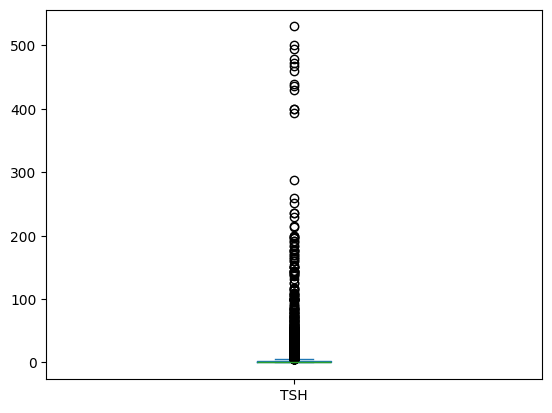

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
424,24,F,False,False,False,False,False,False,False,False,...,False,False,False,430.0,0.4,6.0,1.04,6.000000,other,hypothyroid conditions
768,24,M,False,False,False,False,False,False,False,False,...,False,False,False,400.0,0.2,4.0,1.00,4.000000,other,hypothyroid conditions
3074,59,F,False,False,False,False,False,False,False,False,...,False,False,False,530.0,2.0,10.0,1.12,8.500000,other,hypothyroid conditions
3345,18,F,False,False,False,False,False,False,False,False,...,False,False,False,440.0,0.5,24.0,1.32,18.000000,other,hypothyroid conditions
3502,60,F,True,False,False,False,False,False,False,False,...,False,False,False,400.0,0.5,11.0,1.19,9.099999,other,hypothyroid conditions
4495,2,NaN,False,False,False,False,False,False,False,False,...,False,False,False,472.0,1.7,34.0,1.17,29.000000,STMW,hypothyroid conditions
4853,25,F,False,False,False,False,False,False,False,False,...,False,False,False,468.0,0.7,21.0,1.10,19.000000,other,hypothyroid conditions
5180,18,F,True,False,False,False,False,False,False,False,...,False,False,False,478.0,NaN,45.0,1.30,34.000000,other,hypothyroid conditions
6931,54,F,False,False,False,False,False,False,False,False,...,False,False,False,436.0,NaN,12.0,1.01,12.000000,other,hypothyroid conditions
7218,81,F,False,False,False,False,False,False,False,False,...,False,False,False,494.0,0.5,12.0,1.39,9.000000,SVI,hypothyroid conditions


In [75]:
thyroid_df['TSH'].plot(kind='box')
plt.show()
thyroid_df[thyroid_df['TSH'] > 350]

### T3 (Free T3 - Triiodothyronine)
Normal levels 2.3 - 4.1

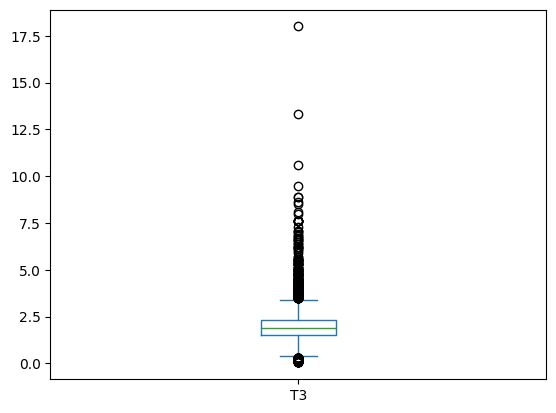

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
7223,23,F,False,False,False,False,False,False,False,False,...,False,False,False,0.065,18.000000,430.0,0.67,642.0,other,hyperthyroid conditions
7692,77,F,False,False,False,False,False,False,False,False,...,False,False,False,0.030,13.299999,410.0,0.79,519.0,other,hyperthyroid conditions


In [ ]:
thyroid_df['T3'].plot(kind='box')
plt.show()

### TT4 (Total T4 - Thyroxine)
Normal levels 64 - 154

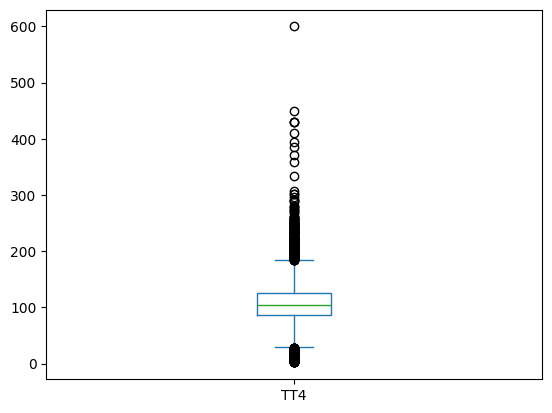

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
6792,34,F,True,False,False,False,False,False,False,False,...,False,False,False,0.065,NaN,600.0,1.1,546.0,other,replacement therapy


In [79]:
thyroid_df['TT4'].plot(kind='box')
plt.show()
thyroid_df[thyroid_df['TT4'] > 500]

### T4U (Free T4 - Thyroxine)
Normal levels 0.8 - 1.8

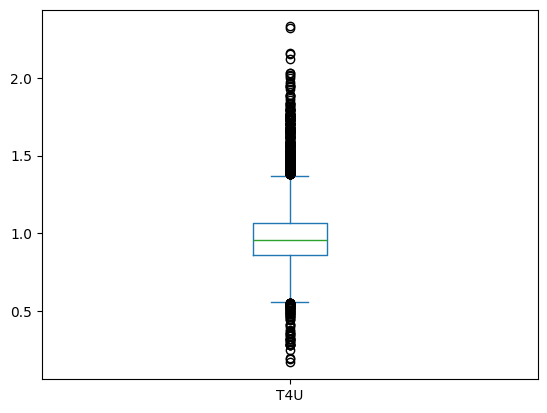

In [81]:
thyroid_df['T4U'].plot(kind='box')
plt.show()

### FTI (Free Thyroxine Index)
Normal levels 1.1 - 4.9

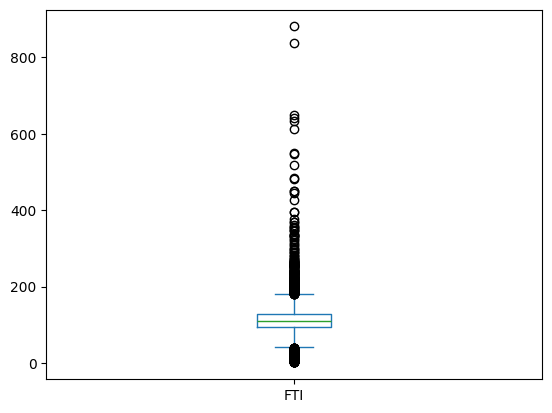

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
654,62,NaN,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,260.0,0.31,839.0,other,hyperthyroid conditions
1603,57,NaN,False,False,False,False,False,False,False,False,...,False,False,False,4.4,2.8,252.0,0.29,881.0,other,discordant results


In [84]:
thyroid_df['FTI'].plot(kind='box')
plt.show()
thyroid_df[thyroid_df['FTI'] > 700]

## Explore Integer Variables

### Age
There are some very clear age data entry errors. It is probably best to drop these rows since there are only a few of them.

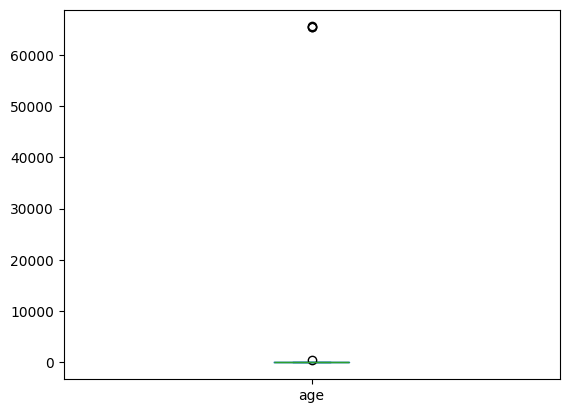

count     9171.000000
mean        73.560680
std       1184.041182
min          1.000000
25%         37.000000
50%         55.000000
75%         68.000000
max      65526.000000
Name: age, dtype: float64

In [85]:
thyroid_df['age'].plot(kind='box')
plt.show()
thyroid_df['age'].describe()

In [ ]:
# Age Data Errors
thyroid_df[thyroid_df['age'] > 100]

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
2975,455,F,False,False,False,False,False,False,False,False,...,False,False,False,1.10,2.0,118.0,1.13,104.0,SVI,negative
5709,65511,M,False,False,False,False,False,False,False,False,...,False,False,False,0.38,2.0,113.0,1.08,104.0,other,negative
6391,65512,M,False,False,False,False,False,False,False,False,...,False,False,False,0.03,2.8,112.0,0.84,133.0,other,negative
8104,65526,F,False,False,False,False,False,False,False,False,...,False,False,False,1.50,NaN,132.0,1.02,129.0,other,negative


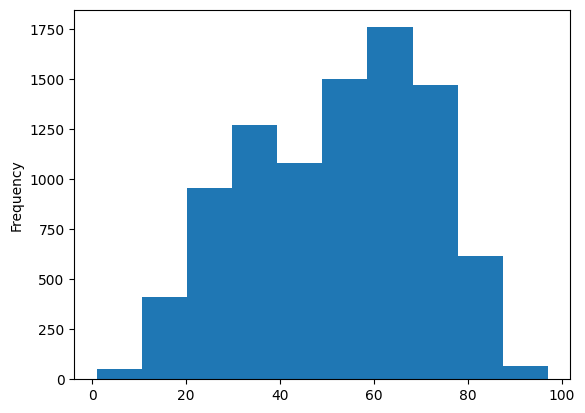

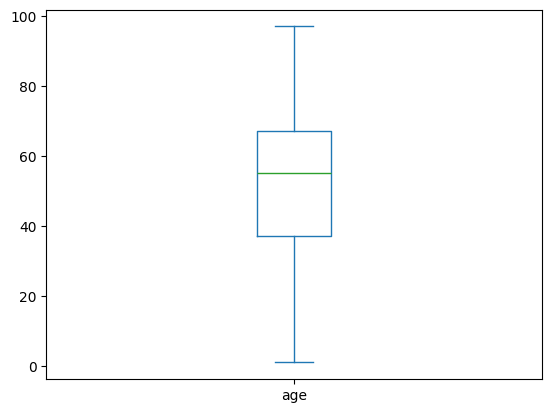

In [87]:
thyroid_df[thyroid_df['age'] < 100]['age'].plot(kind='hist')
plt.show()
thyroid_df[thyroid_df['age'] < 100]['age'].plot(kind='box')
plt.show()


## Explore Categorical Variables

### Sex
This variable has over 1000 missing entries. Should we create a flag variable? Try to impute them based on correlation to other data?

In [91]:
thyroid_df['sex'] = thyroid_df['sex'].astype('category')

<Axes: ylabel='proportion'>

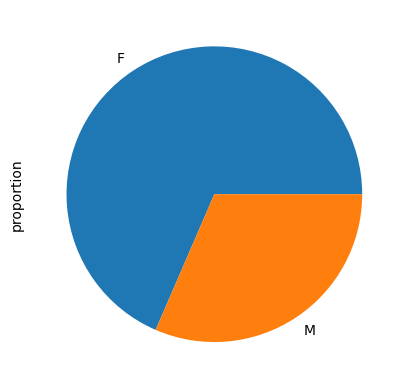

In [ ]:
thyroid_df['sex'].value_counts(normalize=True).plot(kind='pie')
plt.show()

In [94]:
thyroid_df['sex'].isna().sum()

np.int64(307)

### Class
It is probably best to one hot encode (dummify) this variable with negative as the baseline. That way we can include whichever subset of classes we would like to predict in a given model.

In [102]:
thyroid_df['class'] = thyroid_df['class'].astype('category')
thyroid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        9171 non-null   int64   
 1   sex                        8864 non-null   category
 2   on thyroxine               9171 non-null   bool    
 3   query on thyroxine         9171 non-null   bool    
 4   on antithyroid medication  9171 non-null   bool    
 5   sick                       9171 non-null   bool    
 6   pregnant                   9171 non-null   bool    
 7   thyroid surgery            9171 non-null   bool    
 8   I131 treatment             9171 non-null   bool    
 9   query hypothyroid          9171 non-null   bool    
 10  query hyperthyroid         9171 non-null   bool    
 11  lithium                    9171 non-null   bool    
 12  goitre                     9171 non-null   bool    
 13  tumor                      9171 n

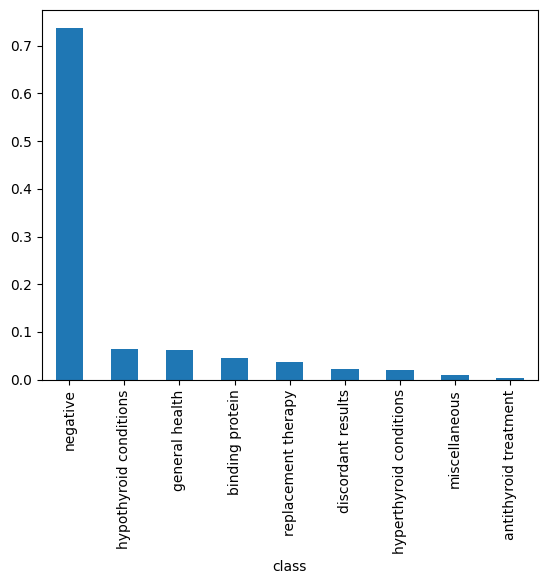

In [97]:
thyroid_df['class'].value_counts(normalize=True).plot(kind='bar')
plt.show()

### Referral Source
I am not sure we should include this one in our models.

<Axes: xlabel='referral source'>

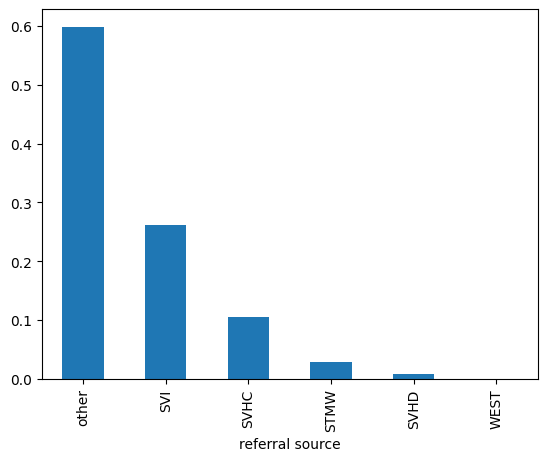

In [ ]:
thyroid_df['referral source'].value_counts(normalize=True).plot(kind='bar')
plt.show()